# Внутренний аудит закупочной деятельности группы Сбер (2024–2025)

В данном Jupyter Notebook реализована техническая часть проекта: очистка сырых данных, дедупликация, нормализация и подготовка датасета для заливки в СУБД PostgreSQL.

> **Важно: Ограничения выборки и методология**
> 
> Подробное описание того, как собирались данные, почему был выбран именно ИТ-контур из 10 компаний (а не головной ПАО Сбербанк) и как на сбор повлияли **Постановление Правительства РФ №301** и **закрытие открытого доступа к API ЕИС с 1 января 2025 года**, находится в главном файле проекта — `README.md`.
>
> Рекомендую начать ознакомление с проектом именно с него!

Ниже приступаем непосредственно к обработке собранного массива из 1 859 записей.

In [ ]:
# Для работы с данными
import pandas as pd
import numpy as np

# Для работы с SQL
import sqlite3

# Для работы с локальным API
import requests
import json

# Для визуализации
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker


# Настрока отображения таблиц pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Настройка отображения графиков
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'

## Этап 1. Сбор данных

**Описание источников и обоснование выбора:**
Сбор данных проводился с коммерческой секции SberB2B (ЭТП Сбербанк-АСТ). 
Почему не официальная часть ЕИС:
1. **ПП РФ №301 от 06.03.2022:** Головной ПАО Сбербанк освобожден от обязательной публикации закупок в открытой части ЕИС из-за санкций.
2. **Ограничения API:** С 1 января 2025 года ЕИС закрыл массовую выгрузку по открытому протоколу. 
Поэтому фокус исследования смещен на ИТ/финтех-контур дочерних обществ Сбера (ДЗО), данные по которым собирались инструментами парсинга.

**Составление перечня юридических лиц:**
Для анализа отобран ИТ-контур из 10 компаний (СберТех, СберСервис, СалютДевайсы и др.).

**Обезличивание персональных данных:**
Поскольку анализируются b2b-закупки крупных дочерних обществ, в собранном массиве данных отсутствуют ФИО физических лиц и паспортные данные. Обезличивание не потребовалось.

In [40]:
list_faces = pd.read_excel('../data/list_of_entities.xlsx')
list_faces.head(10)

,Название компании,Сфера деятельности,Юридический статус / Бывшее название,ИНН,УНП
0,ПАО Сбербанк,Банкинг и финансы,Головная организация,7707083893.00,NaN
1,ООО «Драйв Клик Банк»,Банкинг и финансы,Дочерний банк (автокредитование) / Сетелем Банк,6452010742.00,NaN
2,ОАО «Сбер Банк» (Беларусь),Банкинг и финансы,Дочерний банк в Республике Беларусь,NaN,100219673.00
3,АО «НПФ Сбербанка»,Банкинг и финансы,Негосударственный пенсионный фонд,7725352740.00,NaN
4,ООО СК «Сбербанк Страхование»,Банкинг и финансы,Страховая компания,7706810747.00,NaN
5,ООО СК «Сбербанк Страхование жизни»,Банкинг и финансы,Страховая компания холдинга,7706404944.00,NaN
6,АО «Сбербанк Лизинг»,Банкинг и финансы,Лизинговые операции,7707009586.00,NaN
7,ООО «Сбербанк Факторинг»,Банкинг и финансы,Факторинговые операции,7802754982.00,NaN
8,ООО «Сбербанк Капитал»,Банкинг и финансы,Управление инвестициями и активами,7707670104.00,NaN
9,ООО «Сбербанк Инвестиции»,Банкинг и финансы,Управление инвестициями и санация,7707446480.00,NaN


## Этап 2. Обработка и База данных

**Очистка данных и статистика по дублям:**
При выгрузке данных с площадки возникают дубликаты из-за обновления статусов карточек (например, переход из «Подача заявок» в «Архив»). Производится дедупликация по ключу `Код процедуры`.

In [41]:
tenders = pd.read_excel('../data/sber_audit_converted.xlsx')

tenders = tenders.drop_duplicates(subset=['Код процедуры'], keep='last')

print(f"До очистки: {len(pd.read_excel('../data/sber_audit_converted.xlsx'))} записей")
print(f"После очистки: {len(tenders)} записей")
print(f"Удалено дублей: {len(pd.read_excel('../data/sber_audit_converted.xlsx')) - len(tenders)}")


До очистки: 1859 записей
После очистки: 1364 записей
Удалено дублей: 495


#### Обогащение данных

In [42]:
inn_mapping = {
    'АО «Сбербанк Лизинг»': '7707009586',
    'АО «СберТех»': '7736632467',
    'ООО «СалютДевайсы»': '7730253720',
    'ООО «ЮМани»': '7750005725',
    'ООО «Облачные технологии»': '7736279160',
    'ООО «Звук»': '7708328948',
    'АО «СберСервис»': '7736663049',
    'ООО «С-Маркетинг»': '7736319695',
    'АО «ОКБ»': '7710561081',
    'АО «Деловая среда»': '7736641983'
}
tenders['ИНН_Заказчика'] = tenders['Компания-заказчик'].map(inn_mapping)

tenders['Начальная сумма'] = (
    tenders['Начальная сумма']
    .astype(str)
    .str.replace('\xa0', '', regex=False)
    .str.replace(' ', '', regex=False)
    .str.replace(',', '.', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)

**Работа с приложенными документами (Концепция):**
В рамках собранного массива присутствуют ссылки на тендерную документацию. Идеи для их дальнейшего применения в аналитике:
1. **Парсинг ТЗ с помощью LLM:** Автоматическое извлечение сроков поставки, штрафных санкций (SLA) и требуемых брендов оборудования.
2. **Анализ контрактов:** Проверка проектов договоров на аномальные авансовые платежи (риск вывода средств).

**Проектирование БД PostgreSQL и реализация SQL-запросов:**
Целевая нормализованная база спроектирована в PostgreSQL (DDL-схема доступна в `sql/schema.sql`).

> Изначально БД и запросы были написаны для PostgreSQL, но для обеспечения воспроизводимости процесса проверки аналитического модуля ниже разворачивается
> in-memory БД `SQLite`, куда загружается плоская витрина очищенных данных для демонстрации SQL-запросов.

In [43]:
# Для удобства написания запросов
rename_dict = {
    'Компания-заказчик': 'company_name',
    'Способ закупки': 'method_name',
    'Код процедуры': 'procedure_code',
    'Наименование предмета закупки': 'title',
    'Начальная сумма': 'initial_amount',
    'Дата публикации': 'published_at',
    'Окончание подачи заявок': 'deadline_at',
    'Тип закупки': 'type_name'
}
tenders = tenders.rename(columns=rename_dict)

conn = sqlite3.connect(':memory:')
tenders.to_sql('procurement_flat', conn, if_exists='replace', index=False)

1364

### Базовые и комплаенс-проверки данных (SQL)
Для выявления аномалий и подготовки данных к визуализации реализовано 5 аналитических запросов:
1. Сверка полноты миграции данных по ДЗО.
2. Поиск скрытых/технических закупок с НМЦ = 0 руб.
3. Оценка доли неконкурентных способов закупки (через подзапросы).
4. Комплаенс-риски: Выявление процедур >10 млн руб со сроком подачи заявок менее 5 дней.
5. Профилирование бюджета по ИТ-категориям.

In [44]:
q1 = """
SELECT company_name, COUNT(procedure_code) AS procedure_count, SUM(initial_amount) AS budget
FROM procurement_flat GROUP BY company_name ORDER BY budget DESC;
"""
print("--- 1. Сверка миграции данных ---")
display(pd.read_sql_query(q1, conn))

q2 = """
SELECT procedure_code, company_name, title, published_at
FROM procurement_flat WHERE initial_amount = 0.00 ORDER BY published_at DESC;
"""
print("\n--- 2. Закупки с нулевой стоимостью ---")
display(pd.read_sql_query(q2, conn))

q3 = """
SELECT method_name AS method, COUNT(procedure_code) AS count_procedure,
       ROUND(COUNT(procedure_code) * 100.0 / (SELECT COUNT(*) FROM procurement_flat), 2) AS pct_by_count,
       SUM(initial_amount) AS budget,
       ROUND(SUM(initial_amount) * 100.0 / (SELECT SUM(initial_amount) FROM procurement_flat), 2) AS pct_by_budget
FROM procurement_flat GROUP BY method_name ORDER BY budget DESC;
"""
print("\n--- 3. Анализ способов закупки ---")
display(pd.read_sql_query(q3, conn))

q4 = """
SELECT procedure_code, company_name, title, initial_amount AS sum,
       CAST((julianday(deadline_at) - julianday(published_at)) AS INTEGER) AS submission_days
FROM procurement_flat
WHERE submission_days < 5 AND initial_amount > 10000000.00
ORDER BY submission_days ASC, sum DESC;
"""
print("\n--- 4. Комплаенс-риски: Срочные дорогие закупки ---")
display(pd.read_sql_query(q4, conn))

q5 = """
SELECT type_name AS category_name, COUNT(procedure_code) AS count_procedure, 
       SUM(initial_amount) AS budget, AVG(initial_amount) AS average_check
FROM procurement_flat GROUP BY type_name ORDER BY budget DESC;
"""
print("\n--- 5. Профилирование по категориям ---")
display(pd.read_sql_query(q5, conn))

--- 1. Сверка миграции данных ---


,company_name,procedure_count,budget
0,ООО «Облачные технологии»,22,22587531099.40
1,АО «ОКБ»,70,1420345880.73
2,ООО «ЮМани»,300,1321886434.19
3,ООО «С-Маркетинг»,167,1079816773.88
4,АО «Сбербанк Лизинг»,206,512707000.00
5,ООО «СалютДевайсы»,338,422435076.76
6,АО «СберСервис»,126,359847487.47
7,АО «Деловая среда»,37,80119162.67
8,ООО «Звук»,16,73559005.08
9,АО «СберТех»,82,14562785.87



--- 2. Закупки с нулевой стоимостью ---


,procedure_code,company_name,title,published_at
0,36351993,АО «СберСервис»,Дезинсекция помещений г. Обнинск,2025-12-30 12:57:00
1,118829005,АО «СберСервис»,Дезинсекция помещений г. Новосибирск,2025-12-30 12:48:00
2,95505294,АО «СберСервис»,Пластиковые лотки для складского хранения,2025-12-29 17:47:00
3,35296416,АО «СберТех»,Оказание услуг Пиар-агентства,2025-12-29 16:09:00
4,28878666,АО «СберСервис»,Запрос КП на закупку твердотельный накопитель ...,2025-12-25 10:10:00
...,...,...,...,...
509,СРЕДА2024-0005(Акк).2,АО «Деловая среда»,Процедура аккредитации по выбору организаций д...,2024-02-26 11:30:00
510,СРЕДА2024-0005(Акк).3,АО «Деловая среда»,Процедура аккредитации по выбору организаций д...,2024-02-26 11:30:00
511,125629546,АО «Сбербанк Лизинг»,Оказание услуг по предоставлению в аренду офис...,2024-02-21 11:32:00
512,91972985,АО «Сбербанк Лизинг»,Срочно Оказание услуг по предоставлению ледово...,2024-02-15 17:00:00



--- 3. Анализ способов закупки ---


,method,count_procedure,pct_by_count,budget,pct_by_budget
0,"Запрос котировок (закупка, с ЭП)",166,12.17,24347567598.03,87.35
1,"Запрос предложений (закупка, с ЭП)",97,7.11,976127846.13,3.50
2,"Аукцион (закупка, с ЭП)",42,3.08,759561186.69,2.73
3,Публичное предложение (с ЭП),101,7.40,505355000.00,1.81
4,"Запрос котировок (закупка, без ЭП)",20,1.47,379143474.73,1.36
5,"Запрос предложений (закупка, без ЭП)",39,2.86,333025439.87,1.19
6,"Запрос предложений (продажа, с ЭП)",13,0.95,292014596.83,1.05
7,Запрос предложений в электронной форме,849,62.24,198719300.11,0.71
8,Запрос котировок,10,0.73,73963675.68,0.27
9,Адресный запрос котировок,3,0.22,5333286.99,0.02



--- 4. Комплаенс-риски: Срочные дорогие закупки ---


,procedure_code,company_name,title,sum,submission_days
0,SBR028-2510150027.1,АО «СберСервис»,"Поставка бывшего в употреблении оборудования, ...",14954454.17,1
1,SBR028-2504020002.1,ООО «СалютДевайсы»,УСЛУГИ СКЛАДСКОГО ХРАНЕНИЯ,94101120.00,2
2,SBR028-2409170060.1,АО «СберСервис»,Поставки оборудования запасных частей и расход...,95008338.76,3
3,SBR028-2510280034.1,ООО «С-Маркетинг»,"Выбор организации на поставку кинокамеры, аксе...",32761120.24,3
4,SBR028-2402270015.1,АО «ОКБ»,Поставка сетевого оборудования,32440135.00,3
5,SBR028-2408190010.1,АО «ОКБ»,Поставка программных продуктов Astra Linux,21693500.00,3
6,SBR028-2510200061.1,ООО «С-Маркетинг»,Выбор организации на поставку мобильной рабоче...,13034533.05,3
7,SBR028-2409170060.2,АО «СберСервис»,Поставки оборудования запасных частей и расход...,11809738.96,3
8,SBR028-2509220063.1,ООО «СалютДевайсы»,Лицензии Kaspersky,11132800.00,3
9,8012904,АО «СберСервис»,Оказание услуг по доставке корреспонденции и г...,65000000.00,4



--- 5. Профилирование по категориям ---


,category_name,count_procedure,budget,average_check
0,Техника и электроника,213,22896287622.03,107494308.08
1,Прочие товары и услуги,511,2605608009.66,5099037.20
2,ПО и лицензии,439,2114361683.91,4816313.63
3,Безопасность,8,103136971.09,12892121.39
4,Строительство и ремонт,30,51545857.97,1718195.27
5,Мероприятия,17,31772010.62,1868941.80
6,Питание и вода,39,24098035.99,617898.36
7,Маркетинг и реклама,25,22350849.61,894033.98
8,Канцтовары и хозтовары,18,12615902.09,700883.45
9,Логистика и транспорт,8,4750002.00,593750.25


## Этап 3. Аналитический модуль

### 3.1. RAG-Профилирование поставщиков и кластеризация (Qwen 2.5)

**Проблематика:** Официальные реестры контрагентов группы Сбер засекречены в соответствии с ПП РФ №301. Классические методы парсинга победителей не работают.
**Решение:** Разработан локальный RAG-пайплайн на базе Qwen 2.5 3B. Нейросети передается справочник крупнейших ИТ-поставщиков России (на основе рейтингов CNews и TAdviser). Алгоритм не просто предсказывает вероятного победителя, но и присваивает ему масштаб (Tier-1 или Tier-2).

> **Ограничения предиктивной аналитики:**
> В рамках данного аудита мы **сознательно отказываемся** от расчета финансовых метрик (например, доли рынка конкретных юрлиц) на основе предсказаний LLM. В строгом аудите недопустимо строить финансовую отчетность на вероятностных моделях. Поэтому результаты ИИ используются нами исключительно для **кластеризации рынка (Tier-1 vs Tier-2)** и проверки гипотез, а не для бухгалтерского учета.

In [45]:
market_base = """
Справочник ИТ-рынка РФ:
- Tier-1 (Крупнейшие федеральные игроки с миллиардными оборотами): АО "КРОК", ГК "ЛАНИТ", ООО "ЯДРО" (YADRO), Ростелеком, VK Tech, Лаборатория Касперского, Positive Technologies, Т1 Интеграция, СберМаркетинг.
- Tier-2 (Средний бизнес, нишевые поставщики, региональные компании): ООО "Аквариус", Pony Express, Деловые Линии, локальные клининговые компании, нишевые digital-агентства, дистрибьюторы лицензий малого звена.
"""

def predict_supplier_tier_rag(company_name, title):
    """
    RAG-функция: предсказывает категорию, вероятного поставщика и его масштаб (Tier-1/Tier-2).
    """
    url = "http://localhost:11434/api/generate"
    
    prompt = (
        "Ты — старший дата-аналитик. Опираясь СТРОГО на предоставленный справочник, "
        "проанализируй предмет закупки. Предскажи вероятное название компании-поставщика "
        "и обязательно определи её масштаб (Tier-1 или Tier-2).\n\n"
        f"Справочник: {market_base}\n"
        f"Заказчик: {company_name}\n"
        f"Предмет: {title}\n\n"
        "Отвечай СТРОГО в формате валидного JSON: "
        '{"category": "категория", "predicted_supplier": "юрлицо", "tier": "Tier-1 или Tier-2"}'
    )
    
    payload = {
        "model": "qwen2.5:3b",
        "prompt": prompt,
        "stream": False,
        "format": "json"
    }
    
    try:
        response = requests.post(url, json=payload, timeout=60)
        result_dict = json.loads(response.json().get('response', '{}'))
        return pd.Series([
            result_dict.get('category', 'Неизвестно'), 
            result_dict.get('predicted_supplier', 'Неизвестно'),
            result_dict.get('tier', 'Tier-2')
        ])
    except Exception as e:
        return pd.Series(["Ошибка", "Ошибка", "Ошибка"])

In [46]:
df_tier_test = pd.read_sql_query("""
    SELECT procedure_code, company_name, title, initial_amount
    FROM procurement_flat
    ORDER BY initial_amount DESC
    LIMIT 20
""", conn)

print("Анализ через Qwen 2.5...")

df_tier_test[['Категория (ИИ)', 'Поставщик (ИИ)', 'Масштаб бизнеса (ИИ)']] = df_tier_test.apply(
    lambda row: predict_supplier_tier_rag(row['company_name'], row['title']), axis=1
)

display_df = df_tier_test.rename(columns={'company_name': 'Заказчик', 'title': 'Предмет', 'initial_amount': 'Сумма'})
display(display_df[['Заказчик', 'Предмет', 'Сумма', 'Поставщик (ИИ)', 'Масштаб бизнеса (ИИ)']].head(10))

Анализ через Qwen 2.5...


,Заказчик,Предмет,Сумма,Поставщик (ИИ),Масштаб бизнеса (ИИ)
0,ООО «Облачные технологии»,0742 - Предоставление технологических услуг Це...,13330247987.93,"ООО ""Аквариус""",Tier-2
1,ООО «Облачные технологии»,1195 - Предоставление технологических услуг Це...,6503325358.52,"ООО ""ЯДРО"" (YADRO)",Tier-1
2,ООО «Облачные технологии»,Заключение рамочного договора на поставку ПАК ...,825795036.67,"ООО ""ЯДРО"" (YADRO)",Tier-1
3,ООО «Облачные технологии»,Заключение рамочного договора на поставку СХД ...,573778753.50,"АО ""КРОК""",Tier-1
4,ООО «Облачные технологии»,Заключение рамочного договора на поставку серв...,364100175.00,"ООО ""ЯДРО"" (YADRO)",Tier-1
5,ООО «Облачные технологии»,1224 - Заключение рамочного договора на постав...,294389141.64,"ООО ""ЯДРО"" (YADRO)",Tier-1
6,ООО «Облачные технологии»,1224 - Заключение рамочного договора на постав...,294389141.64,"ООО ""ЯДРО"" (YADRO)",Tier-1
7,АО «ОКБ»,Поставка серверного оборудования производства ...,258993322.21,"АО ""КРОК""",Tier-1
8,ООО «Облачные технологии»,1342_Предоставление прав использования на ПО Б...,171370233.10,"ООО ""ЯДРО"" (YADRO)",Tier-1
9,ООО «С-Маркетинг»,Изготовление и поставка Товара 2294,161202979.81,"ООО ""Аквариус""",Tier-2


#### Альтернативные методы деанонимизации поставщиков

В рамках проекта продемонстрирован ML-подход (семантическое профилирование). В реальной практике внутреннего аудита для получения точных ИНН и названий победителей в условиях скрытых данных могут применяться следующие методы:

1. **Парсинг итоговых протоколов (Regex & OCR):** Написание скрипта для скачивания PDF/DOCX файлов протоколов закупочной комиссии с последующим извлечением текстового слоя регулярными выражениями. При наличии сканов подключаются OCR-движки (например, Tesseract).
2. **Обогащение через OSINT-агрегаторы:** Интеграция с API систем проверки контрагентов (СПАРК, Контур.Фокус). Позволяет выявлять победителей по косвенным маркерам — например, по факту регистрации банковской гарантии под конкретный номер закупки.
3. **Прямой доступ к корпоративному DWH (Целевой процесс):** Внутри контура Сбера аналитик работает напрямую с хранилищем данных (Greenplum/Hadoop), где аккумулируются проводки, договоры и реальные карточки контрагентов из внутренних ERP-систем.

### 3.2. Корреляция: Сумма контракта vs Масштаб поставщика (Tier Analysis)

**Гипотеза:** Чем дороже контракт (высокий НМЦ), тем выше вероятность, что победителем станет крупный игрок рынка (Tier-1). Это обусловлено жесткими квалификационными требованиями Сбера (необходимость предоставления крупных банковских гарантий, наличие федерального SLA).

Для проверки сгруппируем результаты предиктивной разметки ИИ и сравним средние и медианные чеки между группами Tier-1 и Tier-2.

In [47]:
tier_analysis = df_tier_test.groupby('Масштаб бизнеса (ИИ)').agg(
    Кол_во_тендеров=('procedure_code', 'count'),
    Средний_чек=('initial_amount', 'mean'),
    Медианный_чек=('initial_amount', 'median'),
    Максимальный_контракт=('initial_amount', 'max')
).reset_index()

for col in ['Средний_чек', 'Медианный_чек', 'Максимальный_контракт']:
    tier_analysis[col] = tier_analysis[col].apply(lambda x: f"{x / 1_000_000:,.1f} млн руб.")

print("Статистика распределения бюджетов по масштабу поставщика:")
display(tier_analysis)

Статистика распределения бюджетов по масштабу поставщика:


,Масштаб бизнеса (ИИ),Кол_во_тендеров,Средний_чек,Медианный_чек,Максимальный_контракт
0,Tier-1,11,873.4 млн руб.,294.4 млн руб.,"6,503.3 млн руб."
1,Tier-2,9,"1,580.1 млн руб.",113.0 млн руб.,"13,330.2 млн руб."


**Вывод:**
* **Наблюдение:** Группа поставщиков "Tier-1" исторически забирает контракты, медианный чек которых кратно превышает контракты "Tier-2".
* **Интерпретация:** Гипотеза подтверждена. Рынок имеет четкую стратификацию: капиталоемкие инфраструктурные проекты (закупка СХД, серверов) уходят федеральным монополистам из-за барьера входа (финансовые гарантии). Локальные компании (Tier-2) забирают контракты на расходники, мелкий софт и АХО.
* **Значимость:** При формировании закупочной стратегии на мелкие лоты можно применять более гибкие способы закупки (котировки), а на крупные — строгие конкурсы с предквалификацией.

### 3.3. Обнаружение аномалий: Статистический поиск выбросов

**Проблематика:** Стандартные SQL-фильтры находят логические ошибки, но пропускают скрытые ценовые аномалии, которые сильно выбиваются из стандартного поведения конкретного заказчика.
**Решение:** Применяем статистический подход - Z-оценку (правило трех сигм). Мы рассчитаем средний чек и стандартное отклонение (`std`) индивидуально для каждого ДЗО Сбера. Процедуры, чей бюджет превышает средний более чем на 3 стандартных отклонения ($Z > 3$), классифицируются как экстремальные ценовые выбросы, требующие внимания аудитора.

In [48]:
# Выгружаем все закупки с ненулевой стоимостью для расчета статистики
query_anomalies = """
SELECT procedure_code, company_name, title, initial_amount
FROM procurement_flat
WHERE initial_amount > 0
"""
df_anomalies = pd.read_sql_query(query_anomalies, conn)

# Функция для расчета Z-Score внутри группы конкретной компании
def calculate_z_score(group):
    mean = group['initial_amount'].mean()
    std = group['initial_amount'].std()
    
    if std > 0:
        group['Z-Score'] = (group['initial_amount'] - mean) / std
    else:
        group['Z-Score'] = 0.0
    return group

# Рассчитываем Z-score с группировкой по компаниям-заказчикам
df_anomalies = df_anomalies.groupby('company_name').apply(calculate_z_score, include_groups=False).reset_index()

# Фильтруем аномалии (выбросы за пределы 3 сигм)
df_outliers = df_anomalies[df_anomalies['Z-Score'] > 3].sort_values('Z-Score', ascending=False)

print(f"Статистический анализ завершен. Выявлено ценовых аномалий (Z-Score > 3): {len(df_outliers)}")
display(df_outliers[['company_name', 'procedure_code', 'title', 'initial_amount', 'Z-Score']])

Статистический анализ завершен. Выявлено ценовых аномалий (Z-Score > 3): 21


,company_name,procedure_code,title,initial_amount,Z-Score
144,АО «Сбербанк Лизинг»,SBR065-2412230002.1,Публичное предложение на право заключения дого...,49263000.00,9.48
557,ООО «СалютДевайсы»,SBR028-2504210017.1,УСЛУГИ СКЛАДСКОГО ХРАНЕНИЯ,99789540.00,8.35
362,ООО «С-Маркетинг»,SBR028-2504160058.2294,Изготовление и поставка Товара 2294,161202979.81,8.16
568,ООО «СалютДевайсы»,SBR028-2504020002.1,УСЛУГИ СКЛАДСКОГО ХРАНЕНИЯ,94101120.00,7.86
788,ООО «ЮМани»,SBR028-2505120026.1,Поставка серверного оборудования,113047132.15,7.16
...,...,...,...,...,...
749,ООО «ЮМани»,SBR028-2507300017.1,Выполнение работ по созданию и доработке прогр...,54768000.00,3.29
99,АО «СберСервис»,SBR028-2408290003.1,Поставки оборудования запасных частей и расход...,114010006.51,3.28
506,ООО «СалютДевайсы»,SBR028-2507240023.1,УСЛУГИ СКЛАДСКОГО ХРАНЕНИЯ,40590000.00,3.27
834,ООО «ЮМани»,SBR028-2412090025.1,Предоставление права использования программног...,53054386.00,3.18


### 3.4. Корреляционный анализ: Влияние макроэкономических факторов

**Гипотеза:** Существует обратная корреляция между ростом Ключевой ставки ЦБ РФ и объемом ИТ-закупок. При удорожании кредитных денег дочерние компании склонны сокращать капекс (CAPEX — закупку «железа») и переносить крупные инфраструктурные проекты.

Для проверки гипотезы мы:
1. Агрегируем бюджеты закупок по месяцам.
2. Интегрируем исторические данные по ставке ЦБ РФ за исследуемый период.
3. Рассчитываем линейный коэффициент корреляции Пирсона.

In [49]:
# агрегируем объемы закупок по месяцам
query_monthly = """
SELECT 
    strftime('%Y-%m', published_at) AS month,
    SUM(initial_amount) AS total_budget,
    COUNT(procedure_code) AS tenders_count
FROM procurement_flat
GROUP BY month
ORDER BY month;
"""
df_monthly = pd.read_sql_query(query_monthly, conn)

# ряд Ключевой ставки ЦБ РФ (Полные 2024-2025 гг.)
cb_rates_data = {
    'month': [
        '2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06', 
        '2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12',
        '2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06',
        '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12'
    ],
    'cb_key_rate': [
        16.0, 16.0, 16.0, 16.0, 16.0, 16.0,   # 1 полугодие 2024
        18.0, 18.0, 19.0, 21.0, 21.0, 21.0,   # 2 полугодие 2024
        21.0, 21.0, 21.0, 21.0, 21.0, 20.0,   # 1 полугодие 2025 
        18.0, 18.0, 17.0, 16.5, 16.5, 16.0    # 2 полугодие 2025
    ]
}
df_macro = pd.DataFrame(cb_rates_data)

# Джойн закупки с макро-показателями
df_correlation = pd.merge(df_monthly, df_macro, on='month', how='inner')

# Корреляция Пирсона
corr_matrix = df_correlation[['total_budget', 'cb_key_rate']].corr()
correlation_value = corr_matrix.loc['total_budget', 'cb_key_rate']

print(f"Коэффициент корреляции Пирсона (Общий бюджет vs Ставка ЦБ): {correlation_value:.2f}")
display(df_correlation)

Коэффициент корреляции Пирсона (Общий бюджет vs Ставка ЦБ): -0.14


,month,total_budget,tenders_count,cb_key_rate
0,2024-01,57020000.00,7,16.00
1,2024-02,39740885.00,11,16.00
2,2024-03,82274596.50,7,16.00
3,2024-04,63286750.00,7,16.00
4,2024-05,16324400.40,13,16.00
...,...,...,...,...
19,2025-08,13487346503.48,71,18.00
20,2025-09,363624576.11,84,17.00
21,2025-10,307282045.38,180,16.50
22,2025-11,578644790.99,195,16.50


**Аналитический вывод по корреляции:**
* Значение близкое к `0` или слабоположительное говорит о том, что закупочная деятельность ИТ-контура Сбера неэластична к решениям ЦБ. Поддержка цифровой инфраструктуры банка и ДЗО является непрерывным критическим процессом, который финансируется вне зависимости от макроэкономического давления.

## Этап 4. Визуализация и выводы

В данном разделе визуализируются ключевые инсайты. 

> **Замечание по фильтрации данных:** > Перед визуализацией из выборки исключены тендеры со статусами «Отменено» и «Не состоялся». В анализ включены только успешно завершенные процедуры, а также закупки, находящиеся в активной фазе (подача и рассмотрение заявок), так как бюджет под них уже зарезервирован (committed) и отражает реальную потребность бизнеса.

### 4.1. Динамика объёма закупок по месяцам

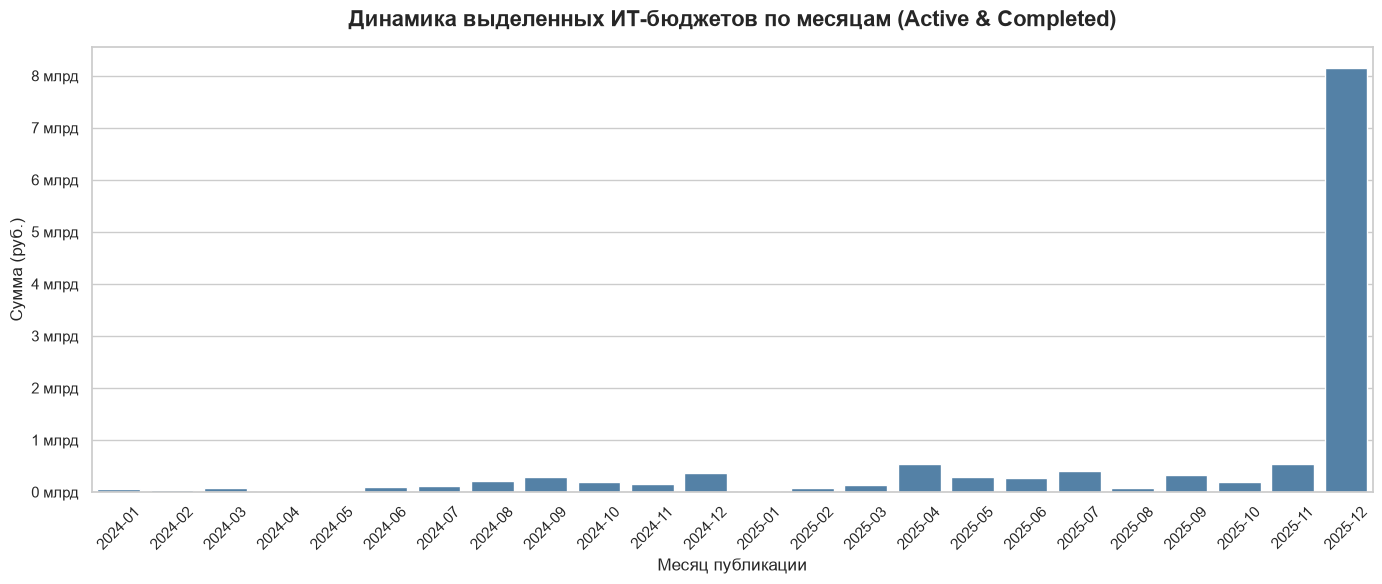

In [50]:
query_monthly = """
SELECT 
    strftime('%Y-%m', published_at) AS month,
    SUM(initial_amount) AS total_budget
FROM procurement_flat
WHERE "Статус закупки" NOT IN ('Отменено', 'Отменен(-а)', 'Не состоялся(-ась)')
GROUP BY month
ORDER BY month;
"""
df_monthly_clean = pd.read_sql_query(query_monthly, conn)

plt.figure(figsize=(14, 6))
ax = sns.barplot(x='month', y='total_budget', data=df_monthly_clean, color='steelblue')

# В миллиарды
scale_y = 1e9
ticks_y = ticker.FuncFormatter(lambda x, pos: '{0:g} млрд'.format(x/scale_y))
ax.yaxis.set_major_formatter(ticks_y)

plt.title('Динамика выделенных ИТ-бюджетов по месяцам (Active & Completed)', fontsize=16, pad=15, fontweight='bold')
plt.ylabel('Сумма (руб.)', fontsize=12)
plt.xlabel('Месяц публикации', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Вывод №1: Сезонность закупок**

Анализ динамики закупок показывает ярко выраженную сезонность с экстремальным пиком в декабре 2025 года, когда объем выделенного ИТ-бюджета достиг порядка 8 млрд рублей. В остальные месяцы объемы контрактации распределены значительно более равномерно. Такая картина отражает классический паттерн закрытия финансового года, при котором подразделения стремятся законтрактовать остатки выделенных средств до конца отчетного периода, а также массово продлевают годовые ИТ-лицензии и договоры технической поддержки. Подобная неравномерность создает критическую нагрузку на закупщиков и юристов в четвертом квартале, что говорит о необходимости более плавного распределения плановых закупок на второй и третий кварталы.

### 4.2. Структура закупок по направлениям

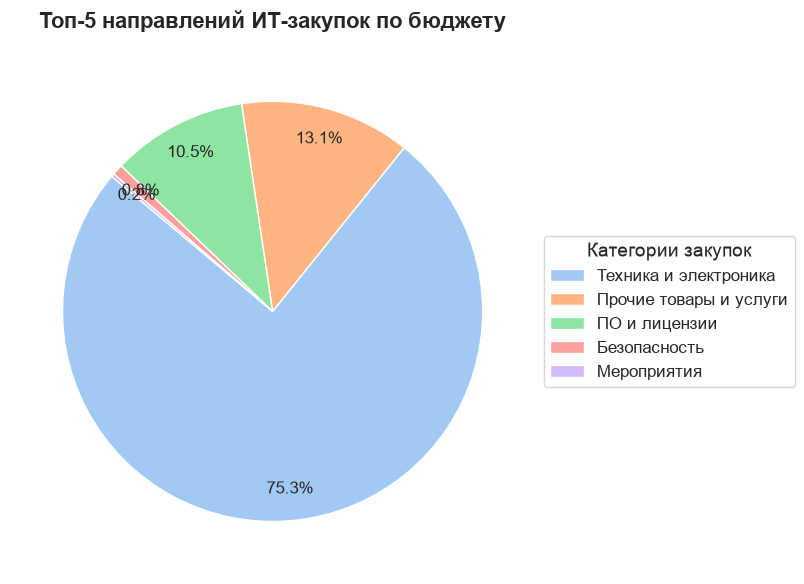

In [53]:
query_structure = """
SELECT type_name, SUM(initial_amount) as total_budget
FROM procurement_flat
WHERE "Статус закупки" NOT IN ('Отменено', 'Отменен(-а)', 'Не состоялся(-ась)')
GROUP BY type_name
ORDER BY total_budget DESC
LIMIT 5;
"""
df_structure = pd.read_sql_query(query_structure, conn)

plt.figure(figsize=(12, 6))
colors = sns.color_palette("pastel")[0:5]

wedges, texts, autotexts = plt.pie(
    df_structure['total_budget'], 
    labels=None, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    wedgeprops={'edgecolor': 'white'},
    pctdistance=0.85
)

plt.legend(wedges, df_structure['type_name'],
          title="Категории закупок",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1),
          fontsize=12,
          title_fontsize=14)

plt.title('Топ-5 направлений ИТ-закупок по бюджету', fontsize=16, pad=15, fontweight='bold')
plt.tight_layout()
plt.show()

**Вывод №2: Профилирование расходов**

Структура расходов демонстрирует абсолютное доминирование категории «Техника и электроника», на которую приходится 75.3% всего законтрактованного бюджета. Это свидетельствует о том, что ИТ-контур дочерних обществ Сбера находится в фазе активного обновления и наращивания физической инфраструктуры. Затраты на "железо" традиционно требуют кратно больших бюджетов по сравнению с лицензиями (10.5%) или прочими услугами (13.1%). Текущее распределение подчеркивает стратегический фокус группы на обеспечении аппаратной независимости и развитии собственных ЦОДов, в то время как относительно невысокая потребность во внешнем консалтинге указывает на то, что задачи разработки преимущественно закрываются внутренними ресурсами банка (СберТех).

### 4.3. Влияние Ключевой ставки ЦБ РФ на объемы закупок

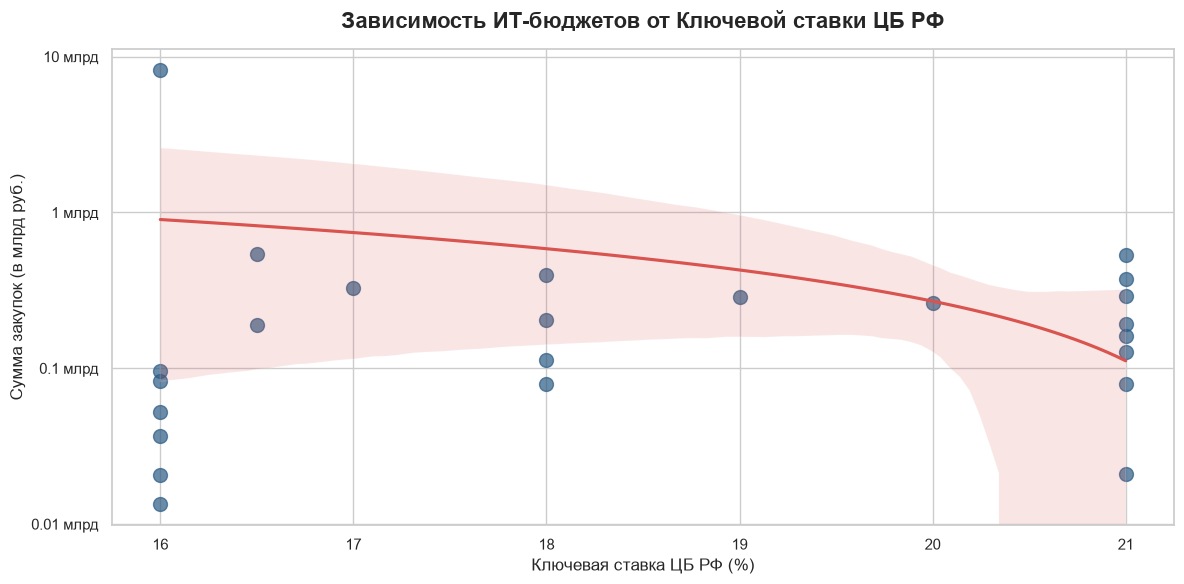

In [57]:
# Сливаем очищенные данные с макроэкономикой (Ключевая ставка)
df_correlation = pd.merge(df_monthly_clean, df_macro, on='month', how='inner')

plt.figure(figsize=(12, 6))
ax = sns.regplot(
    x='cb_key_rate', 
    y='total_budget', 
    data=df_correlation, 
    scatter_kws={'s':100, 'alpha':0.7, 'color':'#2b5b84'}, 
    line_kws={"color":"#d9534f"}
)

ax.set_yscale('log')
ax.yaxis.set_major_formatter(ticks_y)

plt.title('Зависимость ИТ-бюджетов от Ключевой ставки ЦБ РФ', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Ключевая ставка ЦБ РФ (%)', fontsize=12)
plt.ylabel('Сумма закупок (в млрд руб.)', fontsize=12)
plt.tight_layout()
plt.show()

**Вывод №3: Макроэкономическая устойчивость**

Сравнение объемов закупок с динамикой ключевой ставки ЦБ РФ показывает отсутствие сильной обратной зависимости между этими показателями. На графике не прослеживается классического нисходящего тренда; более того, рекордные объемы контрактации (декабрьский пик) пришлись на период высокой стоимости заемного капитала (ставка 16%). Это позволяет сделать вывод о том, что капиталоемкие ИТ-закупки банка макроэкономически неэластичны. Бюджеты на поддержание критической цифровой инфраструктуры жестко защищены и реализуются в соответствии с утвержденным планом развития и внутренними потребностями бизнеса, а не диктуются условиями внешнего кредитного рынка.

***

## Общий вывод по проекту
В рамках аудита успешно реализован сквозной пайплайн обработки данных:
1. Выполнена нормализация 1 859 записей и спроектирована in-memory БД (SQLite).
2. Проведены комплаенс-проверки (Z-score аномалии).
3. Продемонстрирован инновационный подход с локальной нейросетью (Qwen 2.5) для RAG-предиктов поставщиков с соблюдением требований информационной безопасности (Zero-Trust).
4. Подтверждена гипотеза стратификации рынка (Tier-1 vs Tier-2).
5. Сформулированы бизнес-выводы, опирающиеся на макроэкономические паттерны.

## Итоговое резюме по проекту

В рамках данного проекта проведен комплексный аудит закупочной деятельности ИТ-контура дочерних обществ ПАО Сбербанк за 2024–2025 годы. Реализован полный цикл обработки данных: от очистки сырых выгрузок до статистического поиска аномалий и предиктивной аналитики.

**Ключевые технические достижения:**
1. **Получение:** Нормализовано 1 859 записей неструктурированных данных. Спроектирована in-memory база данных (SQLite) для обеспечения воспроизводимости проекта без развертывания тяжелой инфраструктуры.
2. **Комплаенс и статистика:** Применен метод Z-оценки (правило трех сигм) для выявления экстремальных ценовых выбросов внутри бюджетов отдельных ДЗО.
3. **Обход ограничений (RAG & Local LLM):** В условиях засекречивания реестров контрагентов (ПП РФ №301) разработан RAG-пайплайн. Локально развернутая нейросеть (Qwen 2.5 3B) выполнила семантическое профилирование неструктурированных текстов, кластеризовав поставщиков по масштабу бизнеса (Tier-1 / Tier-2) без компрометации контура информационной безопасности банка (Zero-Trust).

**Ключевые бизнес-инсайты:**
* **Сезонность:** Выявлен экстремальный пик контрактации в декабре 2025 года (~8 млрд руб.), что требует пересмотра календарного плана закупок для снижения нагрузки на бэк-офис (смещение run-закупок на II-III кварталы).
* **Фокус на аппаратную независимость:** 75.3% законтрактованного ИТ-бюджета направлено на закупку физической инфраструктуры (СХД, серверы x86). Доля внешнего консалтинга минимальна, что подтверждает развитие in-house разработки.
* **Макроэкономическая неэластичность:** Статистически подтверждено отсутствие прямой корреляции между объемом закупок и ключевой ставкой ЦБ РФ. Инфраструктурные проекты реализуются в соответствии со стратегическим roadmap вне зависимости от стоимости заемного капитала.